<a href="https://colab.research.google.com/github/anirbanghoshsbi/create_knowledge_base/blob/main/hybrid_Rag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!pip uninstall -y transformers
!pip install transformers==4.44.2

In [1]:
!pip install llama-index --q


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


In [11]:
!pip install llama-index-llms-huggingface --q
!pip install transformers accelerate bitsandbytes --q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 7.8 MB/s eta 0:00:00


In [7]:
!pip install llama-index-embeddings-huggingface --q

In [21]:
import json
from typing import Dict, List, Set

from llama_index.core.graph_stores.types import (
    EntityNode,
    Relation,
)

from llama_index.core.graph_stores.simple_labelled import (
    SimplePropertyGraphStore
)


# =========================================================
# CONFIG
# =========================================================

JSON_PATH = "canonical_concepts.json"
'''
NEO4J_CONFIG = {
    "username": "neo4j",
    "password": "password",
    "url": "bolt://localhost:7687",
}
'''

# =========================================================
# LOAD JSON
# =========================================================

with open(JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)


# =========================================================
# GRAPH CONTAINERS
# =========================================================

nodes: List[EntityNode] = []
relations: List[Relation] = []

created_nodes: Set[str] = set()



In [22]:

# =========================================================
# HELPERS
# =========================================================

def normalize(text: str) -> str:
    return (
        text.strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )


def add_node(
    node_id: str,
    name: str,
    label: str,
    properties: Dict = None,
):
    """
    Prevent duplicate node creation.
    """

    if node_id in created_nodes:
        return

    node = EntityNode(
        name=name,
        label=label,
        properties=properties or {},
    )

    # attach stable ID
    node.properties["node_id"] = node_id

    nodes.append(node)

    created_nodes.add(node_id)


def add_relation(
    source_id: str,
    target_id: str,
    relation_type: str,
    properties: Dict = None,
):

    relation = Relation(
        label=relation_type,
        source_id=source_id,
        target_id=target_id,
        properties=properties or {},
    )

    relations.append(relation)


# =========================================================
# BUILD GRAPH
# =========================================================

for item in data:

    # -----------------------------------------------------
    # ROOT CONCEPT NODE
    # -----------------------------------------------------

    concept_id = item["canonical_id"]
    semantic_text = f"""
    Title: {item.get("canonical_title")}

    Framework: {item.get("meta_framework")}

    Core Principle:
    {item.get("core_principle")}

    Implications:
    {chr(10).join(item.get("implications", []))}

    Tensions:
    {chr(10).join(item.get("tensions", []))}

    Child Concepts:
    {chr(10).join(item.get("child_concepts", []))}
    """
    add_node(
        node_id=concept_id,
        name=item["canonical_title"],
        label="CANONICAL_CONCEPT",
        properties={
            "meta_framework": item.get("meta_framework"),
            "core_principle": item.get("core_principle"),
            "semantic_text": semantic_text
        },
    )

    # -----------------------------------------------------
    # META FRAMEWORK NODE
    # -----------------------------------------------------

    framework_name = item.get("meta_framework")

    if framework_name:

        framework_id = f"FRAMEWORK_{normalize(framework_name)}"

        add_node(
            node_id=framework_id,
            name=framework_name,
            label="META_FRAMEWORK",
        )

        add_relation(
            source_id=concept_id,
            target_id=framework_id,
            relation_type="BELONGS_TO_FRAMEWORK",
        )

    # -----------------------------------------------------
    # IMPLICATION NODES
    # -----------------------------------------------------

    for idx, implication in enumerate(
        item.get("implications", [])
    ):

        implication_id = (
            f"{concept_id}_IMPLICATION_{idx}"
        )

        add_node(
            node_id=implication_id,
            name=implication,
            label="IMPLICATION",
        )

        add_relation(
            source_id=concept_id,
            target_id=implication_id,
            relation_type="HAS_IMPLICATION",
        )

    # -----------------------------------------------------
    # TENSION NODES
    # -----------------------------------------------------

    for idx, tension in enumerate(
        item.get("tensions", [])
    ):

        tension_id = (
            f"{concept_id}_TENSION_{idx}"
        )

        add_node(
            node_id=tension_id,
            name=tension,
            label="TENSION",
        )

        add_relation(
            source_id=concept_id,
            target_id=tension_id,
            relation_type="HAS_TENSION",
        )

    # -----------------------------------------------------
    # CHILD CONCEPT NODES
    # -----------------------------------------------------

    for child in item.get("child_concepts", []):

        child_id = (
            f"CHILD_{normalize(child)}"
        )

        add_node(
            node_id=child_id,
            name=child,
            label="CHILD_CONCEPT",
        )

        add_relation(
            source_id=concept_id,
            target_id=child_id,
            relation_type="HAS_CHILD_CONCEPT",
        )


# =========================================================
# CONNECT TO NEO4J
# =========================================================

graph_store = SimplePropertyGraphStore()



In [23]:

# =========================================================
# UPSERT GRAPH
# =========================================================

print(f"Total Nodes: {len(nodes)}")
print(f"Total Relations: {len(relations)}")

graph_store.upsert_nodes(nodes)
graph_store.upsert_relations(relations)

print("Graph successfully loaded into Neo4j.")

Total Nodes: 403
Total Relations: 382
Graph successfully loaded into Neo4j.


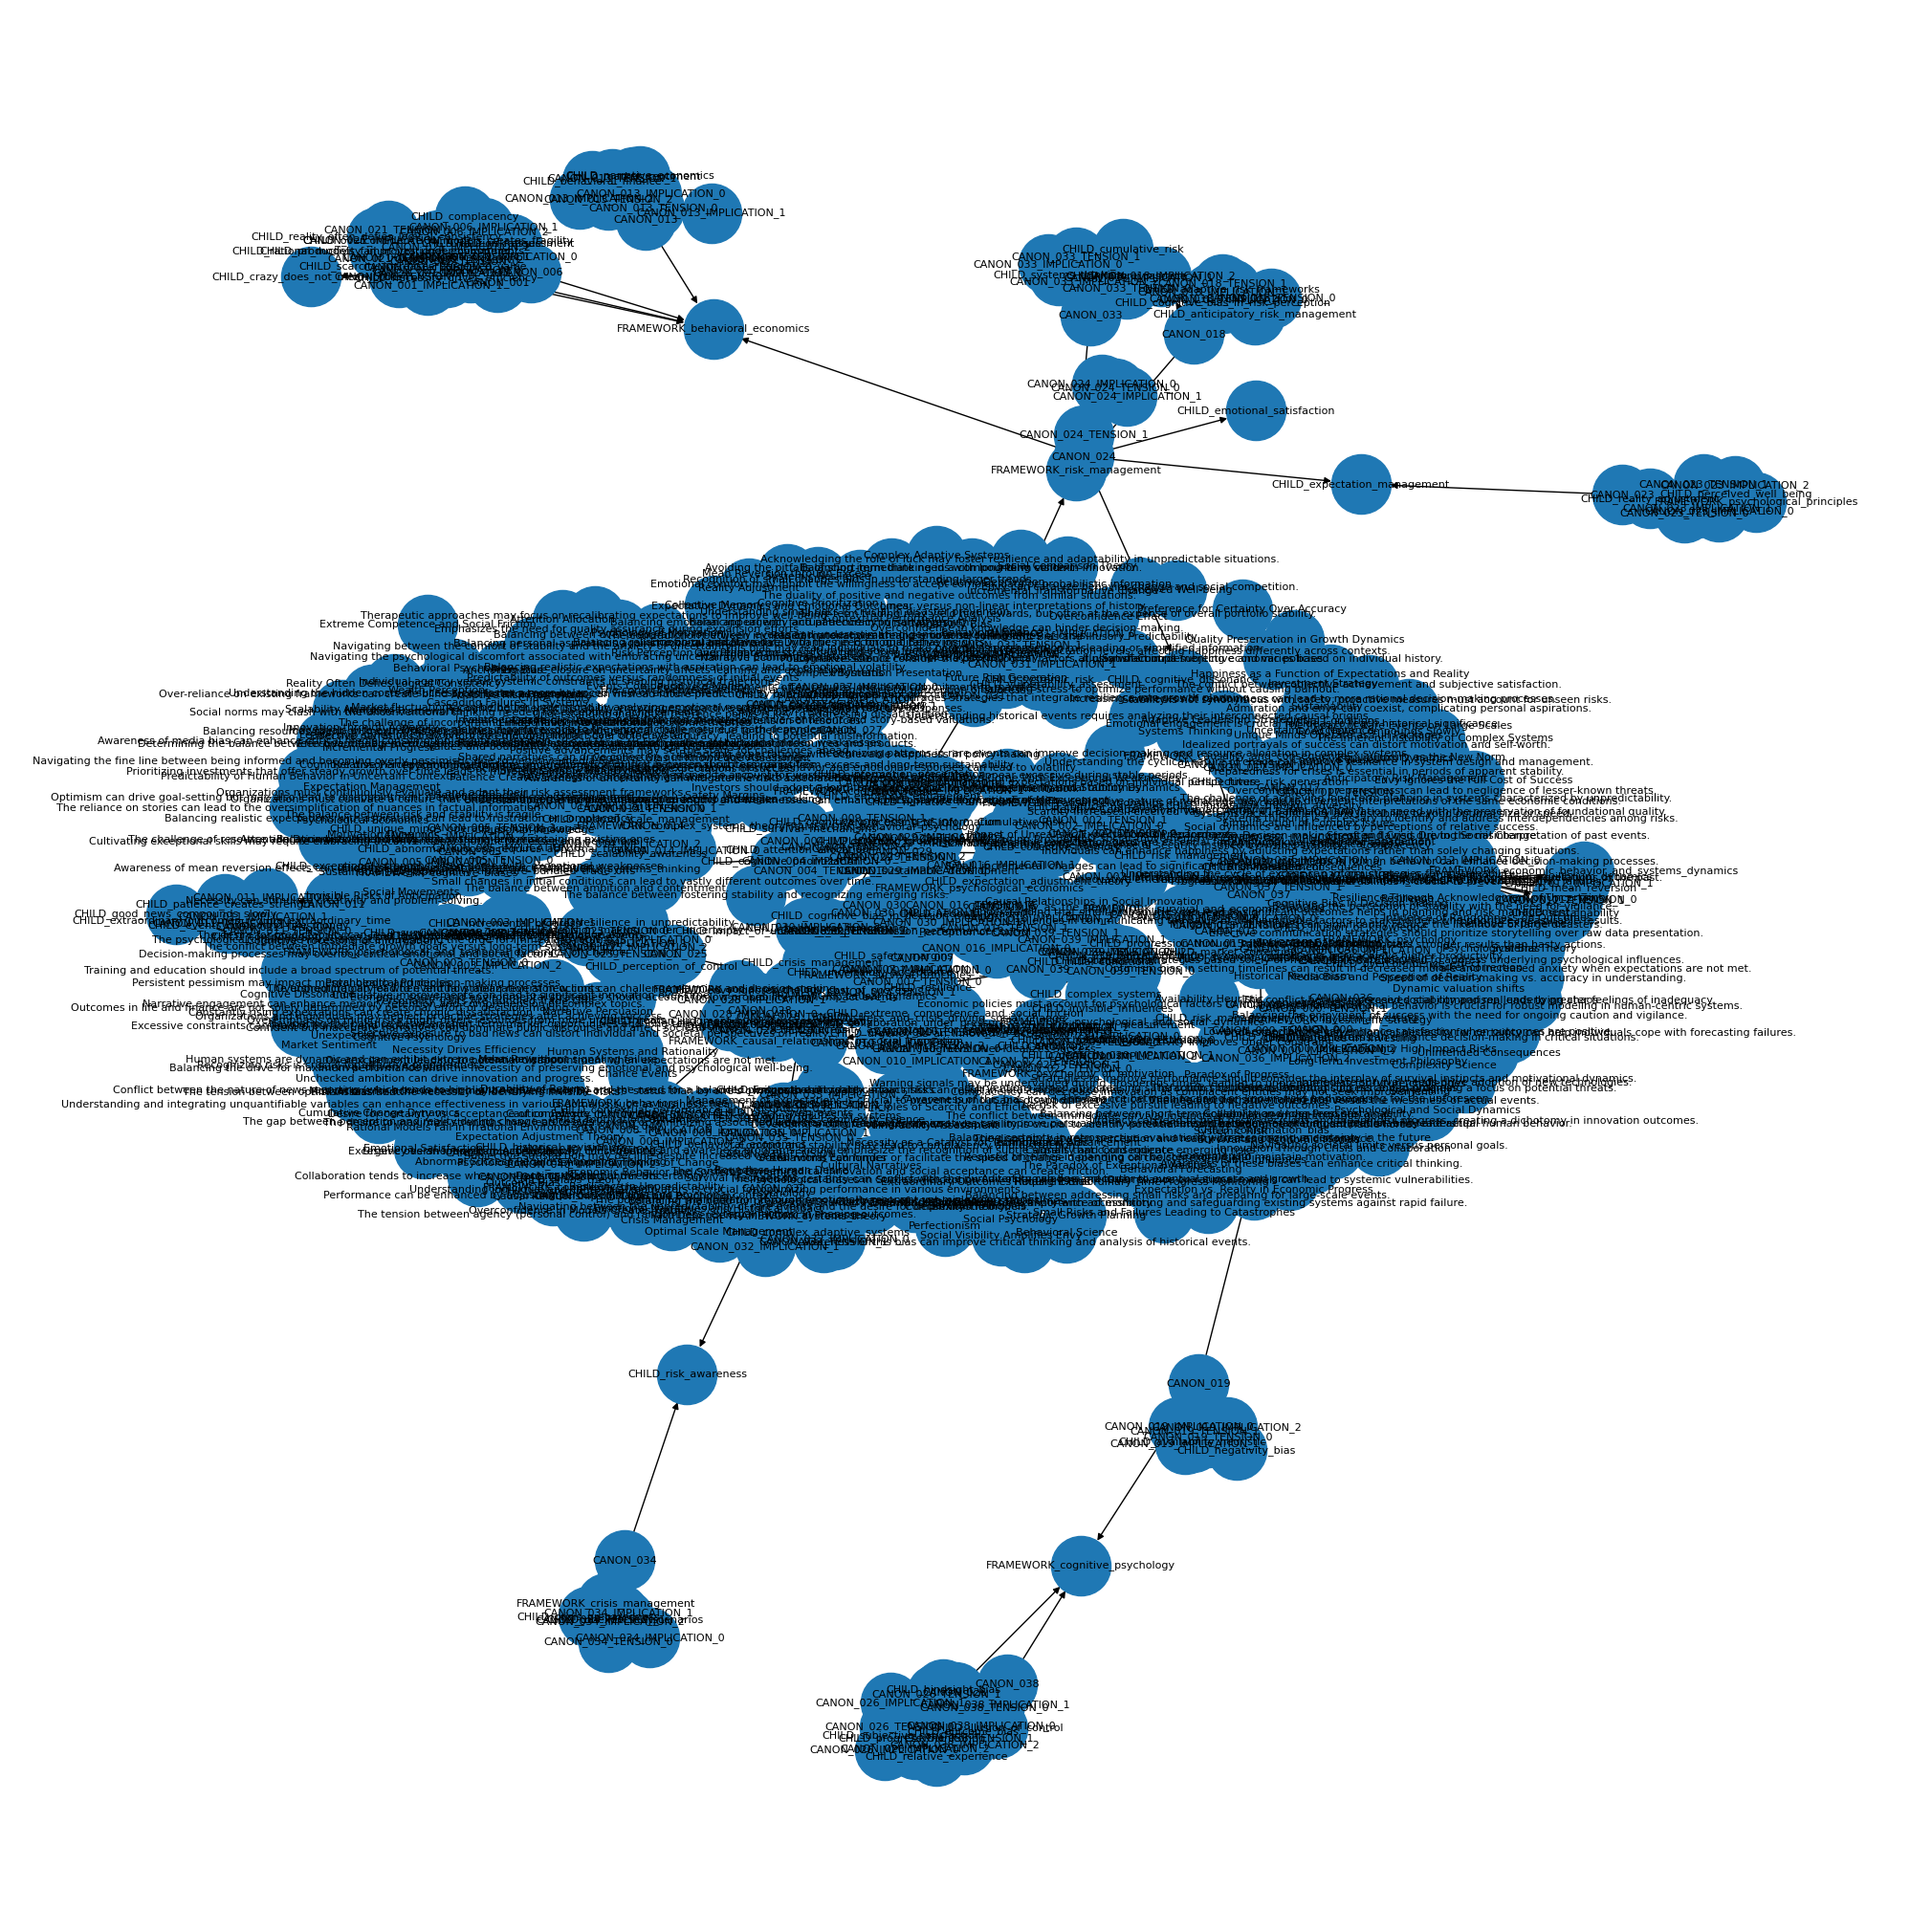

In [24]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

for node in nodes:
    G.add_node(node.name)

for rel in relations:
    G.add_edge(
        rel.source_id,
        rel.target_id,
        label=rel.label
    )

plt.figure(figsize=(20,20))

nx.draw(
    G,
    with_labels=True,
    node_size=2000,
    font_size=8
)

plt.show()

In [25]:
print(len(nodes))
print(len(relations))

print(nodes[:5])
print(relations[:5])

403
382
[EntityNode(label='CANONICAL_CONCEPT', embedding=None, properties={'meta_framework': 'Causal Dynamics', 'core_principle': 'Minor initial events can significantly influence the trajectory of complex systems through cascading causal chains.', 'semantic_text': '\n    Title: Path Dependency in Historical Processes\n\n    Framework: Causal Dynamics\n\n    Core Principle:\n    Minor initial events can significantly influence the trajectory of complex systems through cascading causal chains.\n\n    Implications:\n    Small changes in initial conditions can lead to vastly different outcomes over time.\nUnderstanding historical events requires analyzing their interconnected causal origins.\nDecision-making is complex due to the unpredictable nature of path dependency.\n\n    Tensions:\n    Predictability of outcomes versus randomness of initial events.\nLinear versus non-linear interpretations of history.\nIndividual agency versus systemic constraints in shaping historical trajectories.

In [26]:
from llama_index.core import Settings
from llama_index.embeddings.huggingface import (
    HuggingFaceEmbedding
)

Settings.embed_model = HuggingFaceEmbedding(
    model_name="BAAI/bge-small-en-v1.5"
)

In [27]:
from getpass import getpass
import os

from llama_index.core import Settings
from llama_index.llms.openai import OpenAI

# Securely ask for API key
os.environ["OPENAI_API_KEY"] = getpass("Enter OpenAI API Key: ")

# Configure GPT-4o-mini
Settings.llm = OpenAI(
    model="gpt-4o-mini",
    temperature=0.1,
   )

Enter OpenAI API Key: ··········


In [28]:
from llama_index.core import PropertyGraphIndex

index = PropertyGraphIndex.from_existing(
    property_graph_store=graph_store,
)

In [29]:
query_engine = index.as_query_engine(
    include_text=True,
)

In [30]:
response = query_engine.query(
    "What concepts relate to uncertainty?"
)

In [33]:
response

Response(response='The concepts that relate to uncertainty include CHILD_crisis_management, CHILD_resilience_in_unpredictability, and CHILD_complex_adaptive_systems.', source_nodes=[NodeWithScore(node=TextNode(id_='2eccc9dd-f57d-4d44-bd26-fe1f0fce6ce6', embedding=None, metadata={}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text='CANON_018 -> HAS_IMPLICATION -> CANON_018_IMPLICATION_0', mimetype='text/plain', start_char_idx=None, end_char_idx=None, text_template='{metadata_str}\n\n{content}'), score=0.0), NodeWithScore(node=TextNode(id_='d3503667-11d8-4eb8-b756-802e35577211', embedding=None, metadata={}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text='CANON_016 -> HAS_TENSION -> CANON_016_TENSION_1', mimetype='text/plain', start_char_idx=None, end_char_idx=None, text_template='{metadata_s

###HYBRID RAG

In [34]:
# =========================================================
# INSTALLS
# =========================================================

# !pip install llama-index
# !pip install llama-index-llms-openai
# !pip install llama-index-embeddings-huggingface
# !pip install sentence-transformers
# !pip install networkx


# =========================================================
# IMPORTS
# =========================================================

import json
import os
import networkx as nx

from getpass import getpass

from llama_index.core import (
    Settings,
    VectorStoreIndex,
)

from llama_index.core.schema import TextNode

from llama_index.embeddings.huggingface import (
    HuggingFaceEmbedding
)

from llama_index.llms.openai import OpenAI


# =========================================================

# =========================================================
# SETTINGS
# =========================================================

# EMBEDDINGS
Settings.embed_model = HuggingFaceEmbedding(
    model_name="BAAI/bge-small-en-v1.5"
)

# LLM
Settings.llm = OpenAI(
    model="gpt-4o-mini",
    temperature=0.1,
    max_tokens=512,
)


# =========================================================
# LOAD JSON
# =========================================================

JSON_PATH = "canonical_concepts.json"

with open(JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)


# =========================================================
# BUILD NETWORKX GRAPH
# =========================================================

G = nx.DiGraph()

for item in data:

    canonical_id = item["canonical_id"]

    G.add_node(
        canonical_id,

        title=item.get("canonical_title"),

        framework=item.get("meta_framework"),

        principle=item.get("core_principle"),

        implications=item.get("implications", []),

        tensions=item.get("tensions", []),

        child_concepts=item.get("child_concepts", []),
    )

    # ---------------------------------------------
    # CHILD CONCEPT EDGES
    # ---------------------------------------------

    for child in item.get("child_concepts", []):

        child_id = f"CHILD::{child}"

        G.add_node(
            child_id,
            title=child,
            node_type="child_concept",
        )

        G.add_edge(
            canonical_id,
            child_id,
            relation="HAS_CHILD_CONCEPT",
        )

    # ---------------------------------------------
    # FRAMEWORK EDGES
    # ---------------------------------------------

    framework = item.get("meta_framework")

    if framework:

        framework_id = f"FRAMEWORK::{framework}"

        G.add_node(
            framework_id,
            title=framework,
            node_type="framework",
        )

        G.add_edge(
            canonical_id,
            framework_id,
            relation="BELONGS_TO_FRAMEWORK",
        )



In [35]:

# =========================================================
# CREATE SEMANTIC DOCUMENTS
# =========================================================

semantic_nodes = []

for item in data:

    semantic_text = f"""
Title:
{item.get("canonical_title")}

Framework:
{item.get("meta_framework")}

Core Principle:
{item.get("core_principle")}

Implications:
{" ".join(item.get("implications", []))}

Tensions:
{" ".join(item.get("tensions", []))}

Child Concepts:
{" ".join(item.get("child_concepts", []))}
"""

    node = TextNode(
        text=semantic_text,

        metadata={
            "canonical_id": item["canonical_id"],
            "title": item["canonical_title"],
        }
    )

    semantic_nodes.append(node)



In [36]:

# =========================================================
# BUILD VECTOR INDEX
# =========================================================

vector_index = VectorStoreIndex(
    semantic_nodes
)


# =========================================================
# VECTOR RETRIEVER
# =========================================================

retriever = vector_index.as_retriever(
    similarity_top_k=3
)


# =========================================================
# GRAPH EXPANSION FUNCTION
# =========================================================

def expand_graph_context(canonical_ids, graph, hops=1):

    expanded_context = []

    visited = set()

    for cid in canonical_ids:

        if cid not in graph:
            continue

        # -----------------------------------------
        # ORIGINAL NODE
        # -----------------------------------------

        node_data = graph.nodes[cid]

        expanded_context.append(
            f"""
CONCEPT:
{node_data.get('title')}

FRAMEWORK:
{node_data.get('framework')}

PRINCIPLE:
{node_data.get('principle')}
"""
        )

        visited.add(cid)

        # -----------------------------------------
        # NEIGHBORS
        # -----------------------------------------

        neighbors = nx.single_source_shortest_path_length(
            graph,
            cid,
            cutoff=hops
        )

        for neighbor_id in neighbors:

            if neighbor_id in visited:
                continue

            visited.add(neighbor_id)

            neighbor_data = graph.nodes[neighbor_id]

            expanded_context.append(
                f"""
RELATED NODE:
{neighbor_data.get('title')}

NODE TYPE:
{neighbor_data.get('node_type', 'concept')}
"""
            )

    return "\n".join(expanded_context)


# =========================================================
# HYBRID GRAPH RAG QUERY
# =========================================================

def hybrid_graphrag_query(query):

    # ---------------------------------------------
    # STEP 1: VECTOR RETRIEVAL
    # ---------------------------------------------

    retrieved_nodes = retriever.retrieve(query)

    canonical_ids = []

    semantic_context = []

    for node in retrieved_nodes:

        semantic_context.append(node.text)

        cid = node.metadata.get("canonical_id")

        if cid:
            canonical_ids.append(cid)

    # ---------------------------------------------
    # STEP 2: GRAPH EXPANSION
    # ---------------------------------------------

    graph_context = expand_graph_context(
        canonical_ids,
        G,
        hops=1
    )

    # ---------------------------------------------
    # STEP 3: COMBINE CONTEXT
    # ---------------------------------------------

    final_context = f"""
SEMANTIC CONTEXT
================

{"".join(semantic_context)}

GRAPH CONTEXT
=============

{graph_context}
"""

    # ---------------------------------------------
    # STEP 4: LLM SYNTHESIS
    # ---------------------------------------------

    prompt = f"""
You are a reasoning engine operating over a knowledge graph.

Answer the user question using BOTH:
1. semantic meaning
2. graph relationships

USER QUESTION:
{query}

CONTEXT:
{final_context}

Provide:
- key concepts
- relationships
- causal connections
- synthesis
"""

    response = Settings.llm.complete(prompt)

    return response.text



In [37]:

# =========================================================
# TEST
# =========================================================

answer = hybrid_graphrag_query(
    "What concepts relate to uncertainty?"
)

print("\n====================")
print("HYBRID GRAPH RAG")
print("====================\n")

print(answer)


HYBRID GRAPH RAG

To address the user question regarding concepts that relate to uncertainty, we can analyze both the semantic meaning and the graph relationships.

### Key Concepts Related to Uncertainty

1. **Resilience**: The ability to withstand and adapt to challenges, which is enhanced by acknowledging uncertainty.
2. **Safety Margins**: Protective measures that account for potential risks and uncertainties, ensuring preparedness.
3. **Uncertainty Acceptance**: The recognition and acceptance of uncertainty as a fundamental aspect of decision-making.
4. **Crisis Management**: Strategies and practices designed to prepare for and respond to unexpected events, emphasizing the importance of recognizing uncertainty.
5. **Risk Awareness**: The understanding of potential risks that arise from uncertainty, crucial for effective decision-making.
6. **Complex Adaptive Systems**: Systems that are dynamic and can evolve in response to uncertainties, highlighting the need for flexibility and 